In [44]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import imblearn
from imblearn.over_sampling import SMOTE

In [12]:
#importing csv file
data=pd.read_csv(r'C:\Users\sindh\Desktop\smartlender application\Dataset\loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


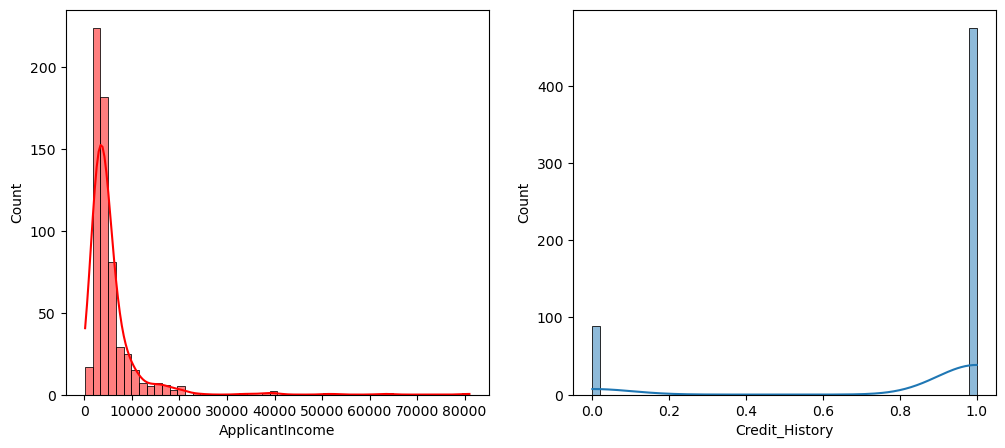

In [13]:
#plotting the using distplot
# plotting using histplot (recommended)

plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data['ApplicantIncome'], color='r', kde=True)

plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)

plt.show()

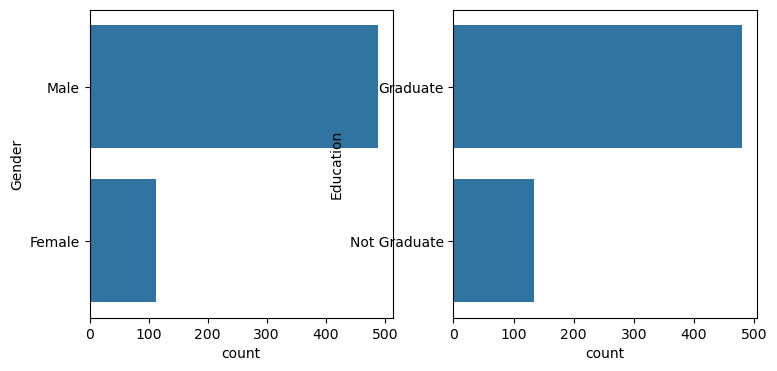

In [14]:
#plotting the count plot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(data['Gender'])
plt.subplot(1,4,2)
sns.countplot(data['Education'])
plt.show()

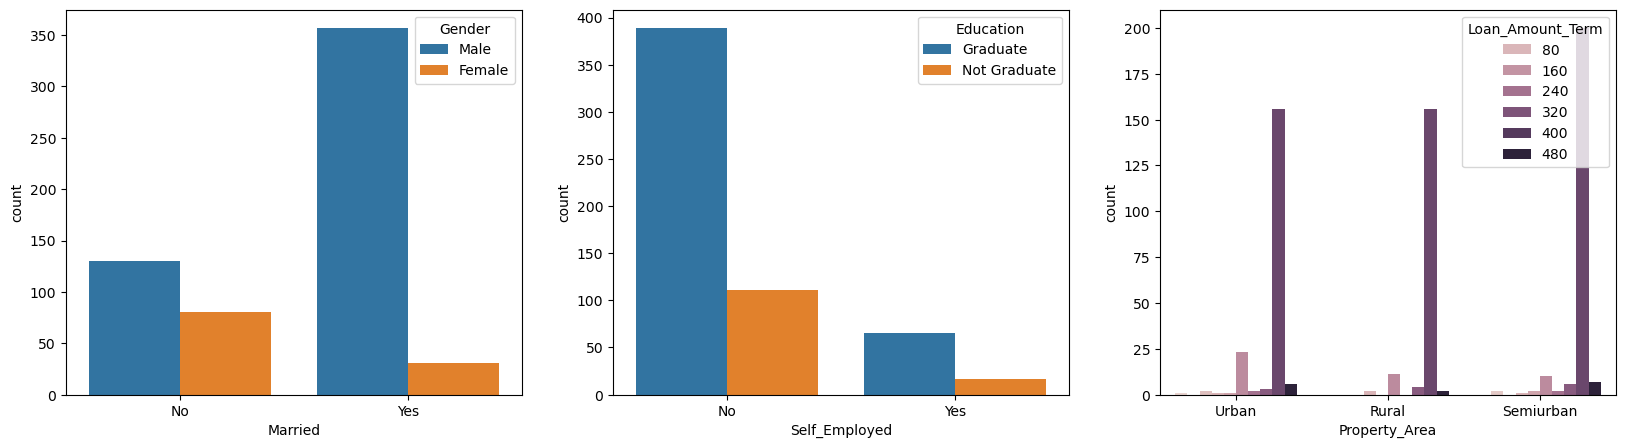

In [15]:
#visualising two columns against each other
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')

plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')

plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

plt.show()

C:\Users\sindh\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\sindh\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\sindh\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


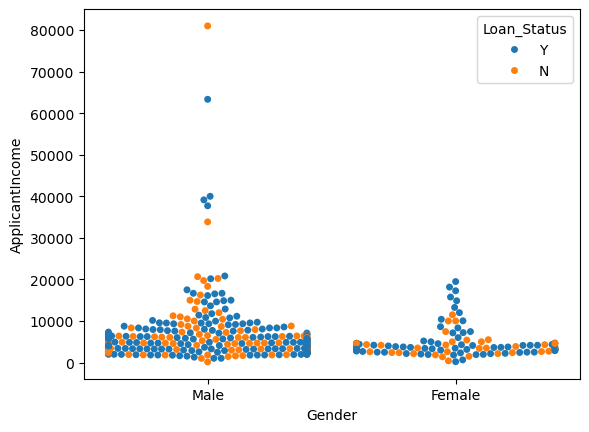

In [16]:
#visualized based gender and income what would be the application status
# Visualize the application status based on gender and applicant income

sns.swarmplot(
    data=data,
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status'
)

plt.show()

In [17]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode().iloc[0])
data['Married'] = data['Married'].fillna(data['Married'].mode().iloc[0])

data['Dependents'] = data['Dependents'].str.replace('+', '', regex=False)
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode().iloc[0])

data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode().iloc[0])

data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode().iloc[0])

data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode().iloc[0])

In [18]:
data['Gender'] = data['Gender'].map({'Female':1,'Male':0})

data['Married'] = data['Married'].map({'Yes':1,'No':0})

data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})

data['Self_Employed'] = data['Self_Employed'].map({'Yes':1,'No':0})

data['Property_Area'] = data['Property_Area'].map({
    'Urban':2,
    'Semiurban':1,
    'Rural':0
})

data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

data['Dependents'] = data['Dependents'].astype(int)

In [19]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [20]:
data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            614 non-null    object
 1   Gender             614 non-null    int64 
 2   Married            614 non-null    int64 
 3   Dependents         614 non-null    int64 
 4   Education          614 non-null    int64 
 5   Self_Employed      614 non-null    int64 
 6   ApplicantIncome    614 non-null    int64 
 7   CoapplicantIncome  614 non-null    int64 
 8   LoanAmount         614 non-null    int64 
 9   Loan_Amount_Term   614 non-null    int64 
 10  Credit_History     614 non-null    int64 
 11  Property_Area      614 non-null    int64 
 12  Loan_Status        614 non-null    int64 
dtypes: int64(12), object(1)
memory usage: 62.5+ KB


In [22]:
x = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

In [23]:
print(y.isnull().sum())
print(y.value_counts())

0
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_bal, y_bal = smote.fit_resample(x, y)

In [26]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Store column names before scaling
names = x_bal.columns

# Perform feature scaling
sc = StandardScaler()
x_bal = sc.fit_transform(x_bal)

# Convert the scaled array back to a DataFrame
x_bal = pd.DataFrame(x_bal, columns=names)

# Display the first few rows
x_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-0.411066,-1.162314,-0.688215,0.630358,-0.339009,0.111702,-0.584593,-0.206753,0.288491,0.645064,1.360038
1,-0.411066,0.860352,0.373674,0.630358,-0.339009,-0.119063,-0.024528,-0.206753,0.288491,0.645064,-1.196470
2,-0.411066,0.860352,-0.688215,0.630358,2.949771,-0.407610,-0.584593,-0.978161,0.288491,0.645064,1.360038
3,-0.411066,0.860352,-0.688215,-1.586401,-0.339009,-0.483620,0.291159,-0.306290,0.288491,0.645064,1.360038
4,-0.411066,-1.162314,-0.688215,0.630358,-0.339009,0.139226,-0.584593,-0.045007,0.288491,0.645064,1.360038


In [37]:
# Splitting the balanced dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_bal,
    y_bal,
    test_size=0.33,
    random_state=42
)

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def decisionTree(X_train, X_test, y_train, y_test):

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    # Training accuracy
    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    # Testing accuracy
    y_pred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, y_pred))

In [47]:
# Printing the train accuracy and test accuracy
decisionTree(X_train, X_test, y_train, y_test)

Training Accuracy: 1.0
Testing Accuracy: 0.7777777777777778


In [42]:
# Importing and building the Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def RandomForest(X_train, X_test, y_train, y_test):

    model = RandomForestClassifier()

    model.fit(X_train, y_train)

    # Training accuracy
    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    # Testing accuracy
    yPred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, yPred))

In [43]:
# Printing the train accuracy and test accuracy

RandomForest(X_train, X_test, y_train, y_test)

Training Accuracy: 1.0
Testing Accuracy: 0.7956989247311828


In [48]:
# Importing and building the KNN model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def KNN(X_train, X_test, y_train, y_test):

    model = KNeighborsClassifier()

    model.fit(X_train, y_train)

    # Training accuracy
    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    # Testing accuracy
    yPred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, yPred))

In [49]:
# Printing the train accuracy and test accuracy

KNN(X_train, X_test, y_train, y_test)

Training Accuracy: 0.8601769911504424
Testing Accuracy: 0.7526881720430108


In [50]:
# Importing and building the Gradient Boosting model

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

def XGB(X_train, X_test, y_train, y_test):

    model = GradientBoostingClassifier()

    model.fit(X_train, y_train)

    # Training accuracy
    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    # Testing accuracy
    yPred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, yPred))

In [51]:
# Printing the train accuracy and test accuracy

XGB(X_train, X_test, y_train, y_test)

Training Accuracy: 0.9345132743362832
Testing Accuracy: 0.7885304659498208


In [53]:
from sklearn.ensemble import RandomForestClassifier
import pickle

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save the model
with open('rdf.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [54]:
import pickle

with open('rdf.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Make predictions
predictions = loaded_model.predict(X_test)